<a href="https://colab.research.google.com/github/Ayomide-Fagbolade/tabular_reinforcement_learning/blob/main/tabular_reinforcement_learning%20/notebooks/Exploring_Van_Seijen_Greedy_Expected_Sarsa_as_QLearning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import numpy as np

# 1. Stochastic Grid World
env_frozen = gym.make("FrozenLake-v1", is_slippery=True)

# 2. Discretized Momentum/Control Task (Alternative to CartPole for tabular methods)
# Note: You can discretize continuous observations into bins for tabular Q/Expected Sarsa
env_cart_like = gym.make("MountainCar-v0")


# Test resetting both environments
obs_cart_like, info_cart_like = env_cart_like.reset()
obs_frozen, info_frozen = env_frozen.reset()


print("--- MountainCar-v0 (Cart-like) Info ---")
print("Observation Space:", env_cart_like.observation_space)
print("Observation Bounds:", env_cart_like.observation_space.low, "to", env_cart_like.observation_space.high)
print("Action Space:", env_cart_like.action_space)
print("Initial Observation:", obs_cart_like)
print("Initial Info:", info_cart_like)

print("\n--- FrozenLake-v1 Info ---")
print("Observation Space:", env_frozen.observation_space)
print("Action Space:", env_frozen.action_space)
print("Initial Observation:", obs_frozen)
print("Initial Info:", info_frozen)



# Close environments when done
env_cart_like.close()
env_frozen.close()

--- MountainCar-v0 (Cart-like) Info ---
Observation Space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Observation Bounds: [-1.2  -0.07] to [0.6  0.07]
Action Space: Discrete(3)
Initial Observation: [-0.5140162  0.       ]
Initial Info: {}

--- FrozenLake-v1 Info ---
Observation Space: Discrete(16)
Action Space: Discrete(4)
Initial Observation: 0
Initial Info: {'prob': 1}


In [ ]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

# Define your new environments to test
environments = {
    "FrozenLake": gym.make("FrozenLake-v1", render_mode="rgb_array"),
    "MountainCar": gym.make("MountainCar-v0", render_mode="rgb_array")
}

for name, env in environments.items():
    # Wrap each environment to save MP4 recordings into separate subfolders
    env = RecordVideo(env, video_folder=f"./video_{name}", episode_trigger=lambda e: True)

    obs, info = env.reset()
    done = False

    print(f"Running random agent on {name}...")
    while not done:
        action = env.action_space.sample()  # Random agent
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    env.close()

print("All recordings complete! Check your Colab file explorer for the video folders.")

/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Running random agent on FrozenLake...


/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Running random agent on MountainCar...
All recordings complete! Check your Colab file explorer for the video folders.


Sarsa (On-policy TD): Uses the actually sampled next action $A'$ taken by the $\epsilon$-greedy policy:$$Q(S, A) \leftarrow Q(S, A) + \alpha \left( R + \gamma Q(S', A') - Q(S, A) \right)$$Expected Sarsa: Uses the mathematical expectation over all possible next actions, weighted by their selection probabilities under the current policy:$$Q(S, A) \leftarrow Q(S, A) + \alpha \left( R + \gamma \sum_{a} \pi(a\vert{}S') Q(S', a) - Q(S, A) \right)$$Q-Learning (Off-policy TD): Uses the greedy max action regardless of what the policy actually selects next:$$Q(S, A) \leftarrow Q(S, A) + \alpha \left( R + \gamma \max_{a} Q(S', a) - Q(S, A) \right)$$

Training Sarsa...
Training Expected Sarsa...
Training Greedy Expected Sarsa...
Training Q-Learning...


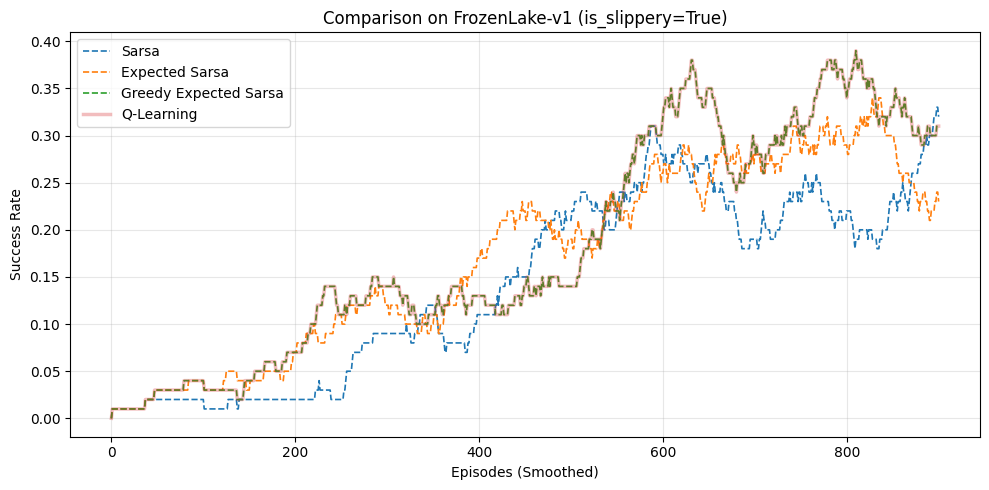

Sarsa: saved complete Q-table -> /content/policies/sarsa_Q_table.npy
Sarsa: saved greedy policy   -> /content/policies/sarsa_policy.npy
Expected Sarsa: saved complete Q-table -> /content/policies/expected_sarsa_Q_table.npy
Expected Sarsa: saved greedy policy   -> /content/policies/expected_sarsa_policy.npy
Greedy Expected Sarsa: saved complete Q-table -> /content/policies/greedy_expected_sarsa_Q_table.npy
Greedy Expected Sarsa: saved greedy policy   -> /content/policies/greedy_expected_sarsa_policy.npy
Q-Learning: saved complete Q-table -> /content/policies/q-learning_Q_table.npy
Q-Learning: saved greedy policy   -> /content/policies/q-learning_policy.npy
Recorded video for Sarsa (success on attempt 3)
Recorded video for Expected Sarsa (success on attempt 3)
Recorded video for Greedy Expected Sarsa (success on attempt 5)
Recorded video for Q-Learning (success on attempt 5)
Sarsa


Expected Sarsa


Greedy Expected Sarsa


Q-Learning


In [ ]:
# ============================================================
# Colab one-time setup:
#   !pip install -q "gymnasium[toy-text]" moviepy
# ============================================================

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

POLICY_DIR = "/content/policies"
VIDEO_DIR = "/content/videos"
os.makedirs(POLICY_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)


def run_algorithm(algo_name, n_episodes=1000, seed=42):
    """Trains one algorithm. Returns (smoothed success-rate history, complete Q-table)."""
    env = gym.make("FrozenLake-v1", is_slippery=True)

    np.random.seed(seed)
    env.action_space.seed(seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))

    alpha = 0.1
    gamma = 0.99
    epsilon = 1.0
    epsilon_min = 0.01
    decay = 0.995

    success_history = []

    def get_action(state, eps):
        if np.random.rand() < eps:
            return np.random.randint(n_actions)
        return np.argmax(Q[state])

    def get_policy_probs(state, eps, n_acts):
        probs = np.ones(n_acts) * (eps / n_acts)
        best_action = np.argmax(Q[state])
        probs[best_action] += (1.0 - eps)
        return probs

    for episode in range(n_episodes):
        if episode == 0:
            state, _ = env.reset(seed=seed)
        else:
            state, _ = env.reset()

        action = get_action(state, epsilon)
        done = False
        total_reward = 0

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            if algo_name == "Sarsa":
                next_action = get_action(next_state, epsilon)
                td_target = reward + gamma * Q[next_state, next_action] * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, next_action

            elif algo_name == "Expected Sarsa":
                next_action = get_action(next_state, epsilon)
                policy_probs = get_policy_probs(next_state, epsilon, n_actions)
                expected_q = np.sum(policy_probs * Q[next_state])
                td_target = reward + gamma * expected_q * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, next_action

            elif algo_name == "Greedy Expected Sarsa":
                greedy_probs = np.zeros(n_actions)
                greedy_probs[np.argmax(Q[next_state])] = 1.0
                expected_q = np.sum(greedy_probs * Q[next_state])

                td_target = reward + gamma * expected_q * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, get_action(next_state, epsilon)

            elif algo_name == "Q-Learning":
                td_target = reward + gamma * np.max(Q[next_state]) * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state = next_state
                action = get_action(state, epsilon)

        epsilon = max(epsilon_min, epsilon * decay)
        success_history.append(1 if total_reward > 0 else 0)

    env.close()

    window = 100
    smoothed = np.convolve(success_history, np.ones(window) / window, mode='valid')
    return smoothed, Q


def slug(algo_name):
    return algo_name.lower().replace(" ", "_")


# ------------------------------------------------------------
# Train all four algorithms
# ------------------------------------------------------------
algorithms = ["Sarsa", "Expected Sarsa", "Greedy Expected Sarsa", "Q-Learning"]
results = {}    # algo_name -> smoothed success-rate history (for the plot)
Q_tables = {}   # algo_name -> complete Q-table

for algo in algorithms:
    print(f"Training {algo}...")
    smoothed, Q = run_algorithm(algo, n_episodes=1000, seed=42)
    results[algo] = smoothed
    Q_tables[algo] = Q

# ------------------------------------------------------------
# Plot: success rate over episodes (unchanged)
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
for algo, hist in results.items():
    if algo == "Q-Learning":
        plt.plot(hist, label=algo, linestyle='-', linewidth=2.5, alpha=0.3)
    else:
        plt.plot(hist, label=algo, linestyle='--', linewidth=1.2, alpha=1)
plt.xlabel("Episodes (Smoothed)")
plt.ylabel("Success Rate")
plt.title("Comparison on FrozenLake-v1 (is_slippery=True)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(POLICY_DIR, "..", "success_rate_comparison.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# Save the COMPLETE best policy for every algorithm:
# both the full Q-table (all 16 states x 4 actions) and the
# greedy action array (argmax per state) derived from it.
# ------------------------------------------------------------
for algo in algorithms:
    Q = Q_tables[algo]
    greedy_policy = np.argmax(Q, axis=1)  # shape (n_states,), one action per state

    q_path = os.path.join(POLICY_DIR, f"{slug(algo)}_Q_table.npy")
    policy_path = os.path.join(POLICY_DIR, f"{slug(algo)}_policy.npy")
    np.save(q_path, Q)
    np.save(policy_path, greedy_policy)
    print(f"{algo}: saved complete Q-table -> {q_path}")
    print(f"{algo}: saved greedy policy   -> {policy_path}")

# ------------------------------------------------------------
# Record a video of each algorithm's saved best policy.
# is_slippery=True means even the best greedy policy can still slide
# into a hole on any given attempt -- so we keep re-rolling with a new
# seed until the rollout actually reaches the goal, and throw away
# (never save) any attempt that ends in a hole.
# ------------------------------------------------------------
MAX_ROLLOUT_STEPS = 100   # safety cap so a looping episode can't run forever
MAX_ATTEMPTS = 50         # give up after this many failed (hole) attempts

for algo in algorithms:
    policy = np.load(os.path.join(POLICY_DIR, f"{slug(algo)}_policy.npy"))

    solved = False
    for attempt in range(MAX_ATTEMPTS):
        # Plain (unwrapped) env first: cheap rollout just to check success,
        # without writing a video file for every failed attempt.
        probe_env = gym.make("FrozenLake-v1", is_slippery=True)
        state, _ = probe_env.reset(seed=1000 + attempt)
        done = False
        reward = 0
        steps = 0
        while not done and steps < MAX_ROLLOUT_STEPS:
            action = policy[state]
            state, reward, terminated, truncated, _ = probe_env.step(action)
            done = terminated or truncated
            steps += 1
        probe_env.close()

        if reward > 0:  # reached the goal, didn't fall in a hole / time out
            # Re-run the SAME seed, this time recording, so we only ever
            # write a video for a successful run.
            record_env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")
            record_env = RecordVideo(
                record_env,
                video_folder=VIDEO_DIR,
                name_prefix=f"frozenlake-{slug(algo)}",
                episode_trigger=lambda ep: True,
            )
            state, _ = record_env.reset(seed=1000 + attempt)
            done = False
            steps = 0
            while not done and steps < MAX_ROLLOUT_STEPS:
                action = policy[state]
                state, reward, terminated, truncated, _ = record_env.step(action)
                done = terminated or truncated
                steps += 1
            record_env.close()
            solved = True
            print(f"Recorded video for {algo} (success on attempt {attempt + 1})")
            break

    if not solved:
        print(f"{algo}: never reached the goal in {MAX_ATTEMPTS} attempts -- no video saved")

# ------------------------------------------------------------
# Display all four videos inline in the notebook
# ------------------------------------------------------------
from IPython.display import Video, display

for algo in algorithms:
    matches = sorted(glob.glob(f"{VIDEO_DIR}/frozenlake-{slug(algo)}*.mp4"))
    if matches:
        print(algo)
        display(Video(matches[-1], embed=True, width=300))

# ------------------------------------------------------------
# (Optional) zip everything up to download from Colab
# ------------------------------------------------------------
# import shutil
# shutil.make_archive("/content/policies", "zip", POLICY_DIR)
# shutil.make_archive("/content/videos", "zip", VIDEO_DIR)
# from google.colab import files
# files.download("/content/policies.zip")
# files.download("/content/videos.zip")

Training Sarsa (seed=0)...
Training Sarsa (seed=1)...
Training Sarsa (seed=2)...
Training Sarsa (seed=3)...
Training Sarsa (seed=4)...
Training Expected Sarsa (seed=0)...
Training Expected Sarsa (seed=1)...
Training Expected Sarsa (seed=2)...
Training Expected Sarsa (seed=3)...
Training Expected Sarsa (seed=4)...
Training Greedy Expected Sarsa (seed=0)...
Training Greedy Expected Sarsa (seed=1)...
Training Greedy Expected Sarsa (seed=2)...
Training Greedy Expected Sarsa (seed=3)...
Training Greedy Expected Sarsa (seed=4)...
Training Q-Learning (seed=0)...
Training Q-Learning (seed=1)...
Training Q-Learning (seed=2)...
Training Q-Learning (seed=3)...
Training Q-Learning (seed=4)...


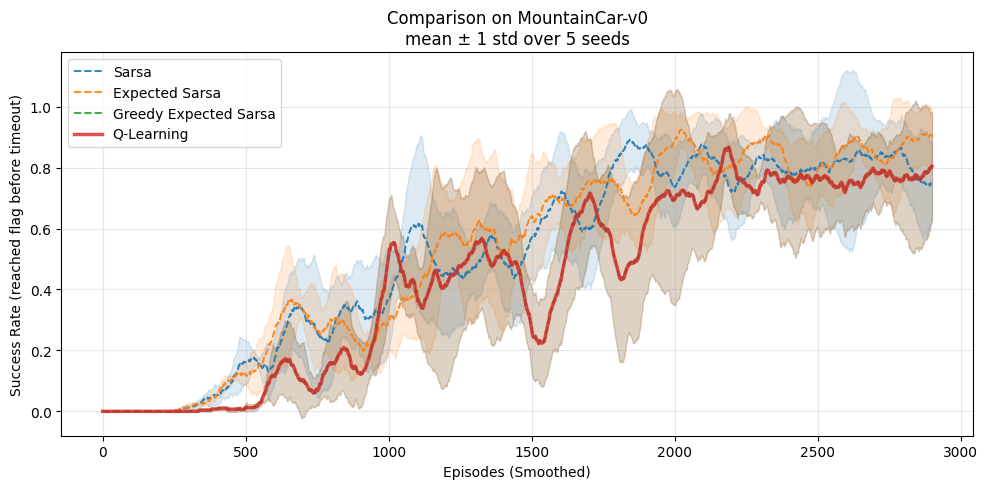

Sarsa: saved complete Q-table -> /content/policies/sarsa_Q_table.npy
Sarsa: saved greedy policy   -> /content/policies/sarsa_policy.npy
Expected Sarsa: saved complete Q-table -> /content/policies/expected_sarsa_Q_table.npy
Expected Sarsa: saved greedy policy   -> /content/policies/expected_sarsa_policy.npy
Greedy Expected Sarsa: saved complete Q-table -> /content/policies/greedy_expected_sarsa_Q_table.npy
Greedy Expected Sarsa: saved greedy policy   -> /content/policies/greedy_expected_sarsa_policy.npy
Q-Learning: saved complete Q-table -> /content/policies/q-learning_Q_table.npy
Q-Learning: saved greedy policy   -> /content/policies/q-learning_policy.npy
Recorded video for Sarsa (success on attempt 2)
Recorded video for Expected Sarsa (success on attempt 1)
Recorded video for Greedy Expected Sarsa (success on attempt 1)
Recorded video for Q-Learning (success on attempt 1)
Sarsa


Expected Sarsa


Greedy Expected Sarsa


Q-Learning


In [ ]:
# ============================================================
# Colab one-time setup:
#   !pip install -q "gymnasium[classic-control]" moviepy
# ============================================================

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

N_BINS = (20, 20)
N_EPISODES = 3000
SEEDS = [0, 1, 2, 3, 4]     # MountainCar training is slower than FrozenLake, so fewer seeds
CANONICAL_SEED = SEEDS[0]   # which run's Q-table/policy gets saved for replay

POLICY_DIR = "/content/policies"
VIDEO_DIR = "/content/videos"
os.makedirs(POLICY_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)


def get_discretizer(env, n_bins=N_BINS):
    obs_low, obs_high = env.observation_space.low, env.observation_space.high
    bin_edges = [np.linspace(obs_low[i], obs_high[i], n_bins[i] - 1) for i in range(2)]

    def discretize(obs):
        pos_bin = np.digitize(obs[0], bin_edges[0])
        vel_bin = np.digitize(obs[1], bin_edges[1])
        return pos_bin * n_bins[1] + vel_bin

    return discretize


def run_algorithm(algo_name, n_episodes=N_EPISODES, seed=42, n_bins=N_BINS):
    """Trains one algorithm for one seed. Returns (smoothed success-rate history, complete Q-table)."""
    env = gym.make("MountainCar-v0")
    np.random.seed(seed)
    env.action_space.seed(seed)

    n_actions = env.action_space.n
    discretize = get_discretizer(env, n_bins)
    n_states = n_bins[0] * n_bins[1]
    Q = np.zeros((n_states, n_actions))

    alpha, gamma = 0.1, 0.99
    epsilon, epsilon_min, decay = 1.0, 0.01, 0.995

    success_history = []

    def get_action(state, eps):
        if np.random.rand() < eps:
            return np.random.randint(n_actions)
        return np.argmax(Q[state])

    def get_policy_probs(state, eps, n_acts):
        probs = np.ones(n_acts) * (eps / n_acts)
        probs[np.argmax(Q[state])] += (1.0 - eps)
        return probs

    for episode in range(n_episodes):
        obs, _ = env.reset(seed=seed) if episode == 0 else env.reset()
        state = discretize(obs)
        action = get_action(state, epsilon)
        done = False
        terminated = False

        while not done:
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_state = discretize(next_obs)

            if algo_name == "Sarsa":
                next_action = get_action(next_state, epsilon)
                td_target = reward + gamma * Q[next_state, next_action] * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, next_action

            elif algo_name == "Expected Sarsa":
                next_action = get_action(next_state, epsilon)
                probs = get_policy_probs(next_state, epsilon, n_actions)
                expected_q = np.sum(probs * Q[next_state])
                td_target = reward + gamma * expected_q * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, next_action

            elif algo_name == "Greedy Expected Sarsa":
                greedy_probs = np.zeros(n_actions)
                greedy_probs[np.argmax(Q[next_state])] = 1.0
                expected_q = np.sum(greedy_probs * Q[next_state])
                td_target = reward + gamma * expected_q * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state, action = next_state, get_action(next_state, epsilon)

            else:  # Q-Learning
                td_target = reward + gamma * np.max(Q[next_state]) * (not done)
                Q[state, action] += alpha * (td_target - Q[state, action])
                state = next_state
                action = get_action(state, epsilon)

        epsilon = max(epsilon_min, epsilon * decay)
        success_history.append(1 if terminated else 0)

    env.close()

    window = 100
    smoothed = np.convolve(success_history, np.ones(window) / window, mode='valid')
    return smoothed, Q


def slug(algo_name):
    return algo_name.lower().replace(" ", "_")


# ------------------------------------------------------------
# Train all four algorithms across multiple seeds
# ------------------------------------------------------------
algorithms = ["Sarsa", "Expected Sarsa", "Greedy Expected Sarsa", "Q-Learning"]
all_runs = {algo: [] for algo in algorithms}
canonical_Q = {}

for algo in algorithms:
    for seed in SEEDS:
        print(f"Training {algo} (seed={seed})...")
        smoothed, Q = run_algorithm(algo, n_episodes=N_EPISODES, seed=seed)
        all_runs[algo].append(smoothed)
        if seed == CANONICAL_SEED:
            canonical_Q[algo] = Q

# ------------------------------------------------------------
# Plot: mean success rate +/- 1 std band across seeds
# ------------------------------------------------------------
plt.figure(figsize=(10, 5))
for algo in algorithms:
    stacked = np.stack(all_runs[algo])
    mean = stacked.mean(axis=0)
    std = stacked.std(axis=0)
    x = np.arange(len(mean))

    if algo == "Q-Learning":
        line, = plt.plot(x, mean, label=algo, linestyle='-', linewidth=2.5, alpha=0.8)
    else:
        line, = plt.plot(x, mean, label=algo, linestyle='--', linewidth=1.4, alpha=0.9)
    plt.fill_between(x, mean - std, mean + std, color=line.get_color(), alpha=0.15)

plt.xlabel("Episodes (Smoothed)")
plt.ylabel("Success Rate (reached flag before timeout)")
plt.title(f"Comparison on MountainCar-v0\nmean \u00b1 1 std over {len(SEEDS)} seeds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(POLICY_DIR, "..", "success_rate_comparison.png"), dpi=150)
plt.show()

# ------------------------------------------------------------
# Save the COMPLETE best policy for every algorithm, taken from the
# canonical seed's run (both the full Q-table and the greedy policy).
# ------------------------------------------------------------
for algo in algorithms:
    Q = canonical_Q[algo]
    greedy_policy = np.argmax(Q, axis=1)

    q_path = os.path.join(POLICY_DIR, f"{slug(algo)}_Q_table.npy")
    policy_path = os.path.join(POLICY_DIR, f"{slug(algo)}_policy.npy")
    np.save(q_path, Q)
    np.save(policy_path, greedy_policy)
    print(f"{algo}: saved complete Q-table -> {q_path}")
    print(f"{algo}: saved greedy policy   -> {policy_path}")

# ------------------------------------------------------------
# Record a video of each algorithm's saved best policy.
# Only ever save a video of a run that actually reaches the flag --
# probe (no video) with an incrementing seed until success, then
# re-run that exact seed with recording on.
# ------------------------------------------------------------
MAX_ATTEMPTS = 30

env_for_discretize = gym.make("MountainCar-v0")
discretize = get_discretizer(env_for_discretize)
env_for_discretize.close()

for algo in algorithms:
    policy = np.load(os.path.join(POLICY_DIR, f"{slug(algo)}_policy.npy"))

    solved = False
    for attempt in range(MAX_ATTEMPTS):
        probe_env = gym.make("MountainCar-v0")
        obs, _ = probe_env.reset(seed=1000 + attempt)
        done = False
        terminated = False
        while not done:
            state = discretize(obs)
            action = policy[state]
            obs, reward, terminated, truncated, _ = probe_env.step(action)
            done = terminated or truncated
        probe_env.close()

        if terminated:  # reached the flag, didn't just time out at 200 steps
            record_env = gym.make("MountainCar-v0", render_mode="rgb_array")
            record_env = RecordVideo(
                record_env,
                video_folder=VIDEO_DIR,
                name_prefix=f"mountaincar-{slug(algo)}",
                episode_trigger=lambda ep: True,
            )
            obs, _ = record_env.reset(seed=1000 + attempt)
            done = False
            while not done:
                state = discretize(obs)
                action = policy[state]
                obs, reward, terminated, truncated, _ = record_env.step(action)
                done = terminated or truncated
            record_env.close()
            solved = True
            print(f"Recorded video for {algo} (success on attempt {attempt + 1})")
            break

    if not solved:
        print(f"{algo}: never reached the flag in {MAX_ATTEMPTS} attempts -- no video saved")

# ------------------------------------------------------------
# Display all four videos inline in the notebook
# ------------------------------------------------------------
from IPython.display import Video, display

for algo in algorithms:
    matches = sorted(glob.glob(f"{VIDEO_DIR}/mountaincar-{slug(algo)}*.mp4"))
    if matches:
        print(algo)
        display(Video(matches[-1], embed=True, width=400))

# ------------------------------------------------------------
# (Optional) zip everything up to download from Colab
# ------------------------------------------------------------
# import shutil
# shutil.make_archive("/content/policies", "zip", POLICY_DIR)
# shutil.make_archive("/content/videos", "zip", VIDEO_DIR)
# from google.colab import files
# files.download("/content/policies.zip")
# files.download("/content/videos.zip")